# TT-12 — Ridge Regression (L2)
## Phân bổ ngân sách quảng cáo đa kênh khi các kênh chạy cùng lúc

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

%matplotlib inline

## Bước 1 — Tạo dữ liệu có đa cộng tuyến rõ rệt

Facebook được sinh ra như một hàm tuyến tính của TV cộng nhiễu nhỏ → tương quan cao với TV (mô phỏng việc chiến dịch lớn bơm tiền vào nhiều kênh cùng lúc).

In [2]:
rng = np.random.default_rng(42)
n = 500
tv = rng.uniform(50, 500, n)
fb = tv * 0.6 + rng.normal(0, 15, n)      # tương quan cao với TV (r ~ 0.95)
gg = rng.uniform(20, 300, n)
doanh_thu = 3.2*tv + 1.8*fb + 2.5*gg + rng.normal(0, 50, n)

df = pd.DataFrame({'TV': tv, 'Facebook': fb, 'Google': gg, 'DoanhThu': doanh_thu})
X = df[['TV', 'Facebook', 'Google']]
y = df['DoanhThu']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.head()

,TV,Facebook,Google,DoanhThu
0,398.280222,260.466351,115.959820,2023.697668
1,247.495298,149.869981,69.625940,1227.675821
2,436.369064,270.533095,209.866337,2512.806355
3,363.815613,217.437620,256.882117,2124.946075
4,92.379807,52.871770,31.271047,449.428305


## Bước 2 — Ma trận tương quan + VIF

VIF (Variance Inflation Factor) được tính thủ công bằng công thức `VIF_i = 1 / (1 - R_i^2)`, trong đó `R_i^2` là hệ số xác định khi hồi quy biến i theo các biến còn lại. VIF > 10 là dấu hiệu đa cộng tuyến nghiêm trọng.

In [3]:
print(X.corr())

def compute_vif(X):
    rows = []
    for col in X.columns:
        y_col = X[col]
        X_others = X.drop(columns=[col])
        r2 = LinearRegression().fit(X_others, y_col).score(X_others, y_col)
        vif = np.inf if r2 >= 1.0 else 1.0 / (1.0 - r2)
        rows.append({'feature': col, 'VIF': vif})
    return pd.DataFrame(rows)

vif_df = compute_vif(X)
vif_df.to_csv('../reports/vif_table.csv', index=False)
vif_df

                TV  Facebook    Google
TV        1.000000  0.980895  0.016020
Facebook  0.980895  1.000000  0.011397
Google    0.016020  0.011397  1.000000


,feature,VIF
0,TV,26.439999
1,Facebook,26.436647
2,Google,1.000750


## Bước 3 — Linear Regression baseline

In [4]:
lr_pipe = Pipeline([('scale', StandardScaler()), ('lr', LinearRegression())])
lr_pipe.fit(X_train, y_train)
lr_coefs = dict(zip(X.columns, lr_pipe['lr'].coef_))
lr_coefs

{'TV': np.float64(406.91919524974793),
 'Facebook': np.float64(140.98923747398135),
 'Google': np.float64(206.73999235716582)}

## Bước 4 — Thí nghiệm ổn định (bootstrap): Linear vs Ridge

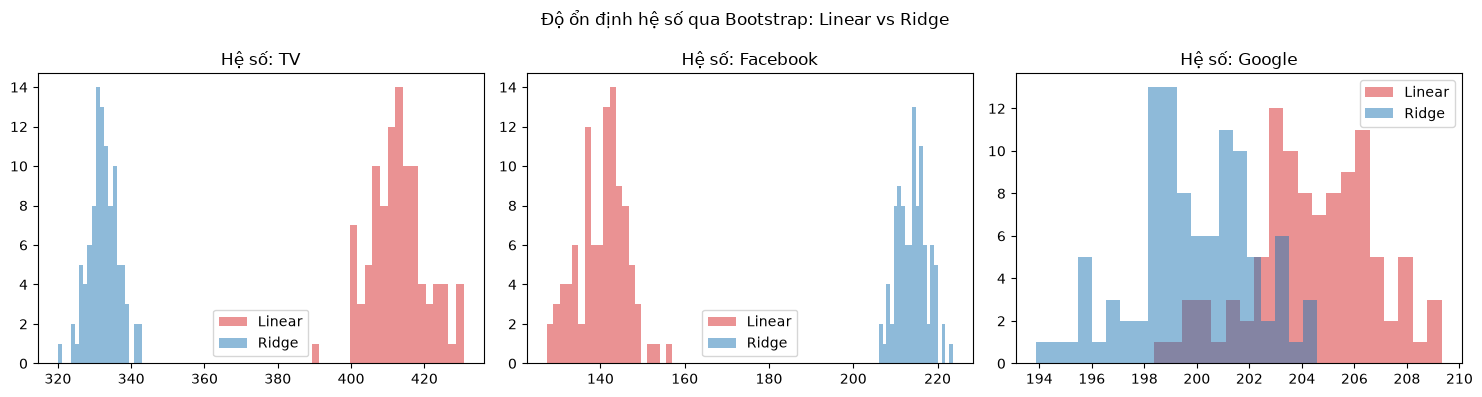

,feature,std_linear,std_ridge
0,TV,7.558479,4.100672
1,Facebook,5.657777,3.538353
2,Google,2.324139,2.261789


In [5]:
n_boot = 100
coefs_lr, coefs_ridge = [], []

for i in range(n_boot):
    sample = df.sample(frac=0.8, random_state=i)
    Xs, ys = sample[['TV', 'Facebook', 'Google']], sample['DoanhThu']
    scaler = StandardScaler().fit(Xs)
    Xs_scaled = scaler.transform(Xs)
    coefs_lr.append(LinearRegression().fit(Xs_scaled, ys).coef_)
    coefs_ridge.append(Ridge(alpha=10).fit(Xs_scaled, ys).coef_)

coefs_lr = np.array(coefs_lr)
coefs_ridge = np.array(coefs_ridge)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, name in enumerate(X.columns):
    axes[i].hist(coefs_lr[:, i], alpha=0.5, label='Linear', bins=20, color='tab:red')
    axes[i].hist(coefs_ridge[:, i], alpha=0.5, label='Ridge', bins=20, color='tab:blue')
    axes[i].set_title(f'Hệ số: {name}')
    axes[i].legend()
plt.suptitle('Độ ổn định hệ số qua Bootstrap: Linear vs Ridge')
plt.tight_layout()
plt.savefig('../reports/bootstrap_he_so.png', dpi=120)
plt.show()

std_compare = pd.DataFrame({
    'feature': X.columns,
    'std_linear': coefs_lr.std(axis=0),
    'std_ridge': coefs_ridge.std(axis=0),
})
std_compare

**Nhận xét:** Độ lệch chuẩn (std) của hệ số Linear Regression cao hơn rõ rệt so với Ridge ở TV và Facebook (hai biến tương quan cao) — nghĩa là Ridge cho hệ số ổn định hơn qua các lần lấy mẫu khác nhau.

## Bước 5 — RidgeCV dò alpha (chỉ trên tập train, tránh rò rỉ dữ liệu)

In [6]:
ridge_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)),
])
ridge_pipe.fit(X_train, y_train)
best_alpha = ridge_pipe['ridge'].alpha_
print('alpha tối ưu:', best_alpha)

alpha tối ưu: 0.001


## Bước 6 — Coefficient path

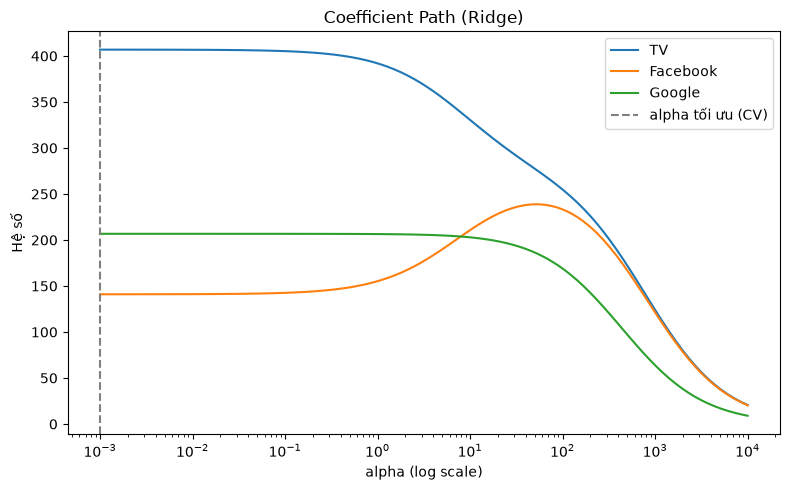

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

alphas = np.logspace(-3, 4, 100)
paths = np.array([Ridge(alpha=a).fit(X_train_scaled, y_train).coef_ for a in alphas])

plt.figure(figsize=(8, 5))
for i, name in enumerate(X.columns):
    plt.plot(alphas, paths[:, i], label=name)
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Hệ số')
plt.axvline(best_alpha, color='gray', linestyle='--', label='alpha tối ưu (CV)')
plt.legend()
plt.title('Coefficient Path (Ridge)')
plt.tight_layout()
plt.savefig('../reports/coefficient_path.png', dpi=120)
plt.show()

## Bước 7 — Đường RMSE train/test theo alpha

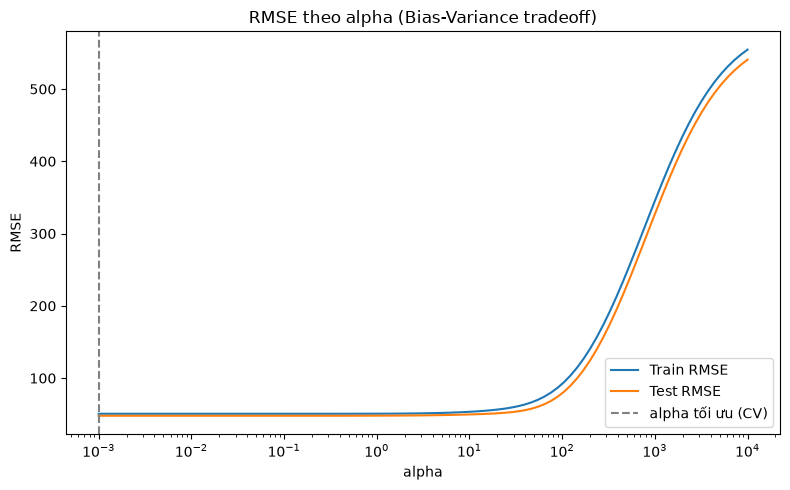

In [8]:
X_test_scaled = scaler.transform(X_test)
train_rmse, test_rmse = [], []

for a in alphas:
    m = Ridge(alpha=a).fit(X_train_scaled, y_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_scaled))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test_scaled))))

plt.figure(figsize=(8, 5))
plt.plot(alphas, train_rmse, label='Train RMSE')
plt.plot(alphas, test_rmse, label='Test RMSE')
plt.xscale('log')
plt.axvline(best_alpha, color='gray', linestyle='--', label='alpha tối ưu (CV)')
plt.legend()
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.title('RMSE theo alpha (Bias-Variance tradeoff)')
plt.tight_layout()
plt.savefig('../reports/rmse_theo_alpha.png', dpi=120)
plt.show()

## Bước 8 — So sánh RMSE Linear vs Ridge trên tập test

In [9]:
rmse_lr_test = np.sqrt(mean_squared_error(y_test, lr_pipe.predict(X_test)))
rmse_ridge_test = np.sqrt(mean_squared_error(y_test, ridge_pipe.predict(X_test)))
print(f'Linear RMSE (test): {rmse_lr_test:.3f}')
print(f'Ridge  RMSE (test): {rmse_ridge_test:.3f}')

Linear RMSE (test): 47.946
Ridge  RMSE (test): 47.946


## Bước 9 — So sánh với Lasso (TT-13) và ElasticNet (TT-14)

In [10]:
lasso_pipe = Pipeline([('scale', StandardScaler()), ('lasso', LassoCV(cv=5, random_state=42))]).fit(X_train, y_train)
elastic_pipe = Pipeline([('scale', StandardScaler()), ('en', ElasticNetCV(cv=5, random_state=42))]).fit(X_train, y_train)

compare_coefs = pd.DataFrame({
    'feature': X.columns,
    'Ridge': ridge_pipe['ridge'].coef_,
    'Lasso': lasso_pipe['lasso'].coef_,
    'ElasticNet': elastic_pipe['en'].coef_,
})
compare_coefs.to_csv('../reports/so_sanh_he_so.csv', index=False)
compare_coefs

,feature,Ridge,Lasso,ElasticNet
0,TV,406.902458,407.752136,220.387401
1,Facebook,141.005297,139.560412,209.578198
2,Google,206.739713,206.115715,137.255987


## Bước 10 — ✍️ Đề xuất phân bổ ngân sách dựa trên hệ số Ridge

In [11]:
ridge_coefs = dict(zip(X.columns, ridge_pipe['ridge'].coef_))
total = sum(abs(v) for v in ridge_coefs.values())
budget_total_vnd = 2_000_000_000  # 2 tỷ / tháng

allocation = []
for k, v in ridge_coefs.items():
    pct = abs(v) / total * 100
    allocation.append({
        'kenh': k,
        'he_so_ridge_chuan_hoa': v,
        'ty_trong_%': pct,
        'de_xuat_ngan_sach_vnd': budget_total_vnd * pct / 100,
    })
alloc_df = pd.DataFrame(allocation)
alloc_df.to_csv('../reports/de_xuat_phan_bo_ngan_sach.csv', index=False)
alloc_df

,kenh,he_so_ridge_chuan_hoa,ty_trong_%,de_xuat_ngan_sach_vnd
0,TV,406.902458,53.919542,1.078391e+09
1,Facebook,141.005297,18.684923,3.736985e+08
2,Google,206.739713,27.395535,5.479107e+08


## Lưu model

In [12]:
joblib.dump(ridge_pipe, '../models/ridge_pipeline.joblib')
print('Đã lưu model.')

Đã lưu model.
